# Inference Speedup Benchmark — Depth Anything v3 (Metric-Large)

> A practical guide to every GPU inference optimization trick in PyTorch,
> benchmarked on a real depth estimation model.

- toc: true
- badges: true
- comments: true
- categories: [pytorch, inference, optimization, gpu, depth-estimation]

How fast can we push a single forward pass of a modern depth estimator on a CUDA GPU?

**Model:** [Depth Anything v3](https://github.com/ByteDance-Seed/depth-anything-3)
— Metric-Large variant (**334 M params**).  DinoV2 ViT-L/14 backbone (304 M) +
DPT depth head (30 M).  Predicts metric depth from a single 504 × 504 image.

**GPU optimizations covered:**

| # | Method | Key idea |
|---|--------|----------|
| 0 | Eager baseline | all extras disabled; clean reference point |
| 1 | `cudnn.benchmark` | auto-tune conv algorithms |
| 2 | `channels_last` | NHWC memory layout |
| 3 | `inference_mode` | stricter than `no_grad` |
| 4 | TF32 matmul | Ampere fast-math for float32 |
| 5 | AMP FP16 | autocast to half precision |
| 6 | AMP BF16 | autocast to bfloat16 |
| 7 | Static FP16 | `model.half()` permanently |
| 7b | SDPA backends | Flash / MemEfficient / Math attention |
| 8–11 | `torch.compile` | Dynamo + Inductor + Triton (4 modes) |
| 12 | JIT Trace + optimize | TorchScript graph fusion |
| 13 | Manual CUDA Graphs | replay captured kernel sequence |
| 14–15 | torchao int8 | GPU-native weight-only quantization |
| 16 | torchao int4 weight-only | 4-bit Triton kernels |
| 17 | ONNX Runtime CUDA EP | ORT graph optimizations |
| 18 | ORT CUDA EP + IO Binding | zero-copy GPU inference |
| 19 | ORT TensorRT EP | TRT engine via ORT |
| 20 | Torch-TensorRT | direct TRT compilation from PyTorch |
| 21 | Triton fused softmax | custom Triton kernel replacing attention softmax |
| 22 | compile fullgraph + freeze | zero graph breaks + Inductor tuning |
| 23–24 | Weight pruning 50 % | unstructured L1 sparsity ± compile |
| 25 | torch.export + AOTInductor | ahead-of-time compiled .so artifact |
| 26 | Multi-stream pipelining | batch splitting across CUDA streams |
| 27 | bitsandbytes int8 | LLM.int8() quantization |
| 28 | bitsandbytes NF4 | 4-bit NormalFloat from QLoRA |
| 29 | FP16 + compile reduce-overhead | the "GPT, Fast" recipe |
| 30 | FP16 + TF32 + cudnn.benchmark | simplest no-compile combo |
| 31 | FP16 + compile reduce-overhead + TF32 | strongest combo |

**Sanity checks:** Every optimization is automatically checked against the baseline
depth map. `bench()` computes MSE on a real-image depth prediction — if the output
diverges, you see a warning and a side-by-side depth visualization.

**Methodology:** Every benchmark cell calls `reset_backends()` first so
optimizations never accidentally stack. A GPU warmup pass runs before each timed
section. Each method runs **5 independent rounds** of `blocked_autorange`; we
report the **median of medians**.

In [1]:
# ── Self-contained installs ──────────────────────────────────────────────
# Uncomment if running on a fresh machine.  Tested with PyTorch 2.5 + CUDA 12.1.
# NOTE: install depth_anything_3 with --no-deps to avoid pulling a newer
# PyTorch that may be incompatible with your CUDA driver.

# %pip install -q torch==2.5.1+cu121 torchvision==0.20.1+cu121 --index-url https://download.pytorch.org/whl/cu121
# %pip install -q "depth_anything_3 @ git+https://github.com/ByteDance-Seed/depth-anything-3" --no-deps
# %pip install -q e3nn einops "evo>=0.3" omegaconf safetensors addict pillow opencv-python-headless
# %pip install -q torchao bitsandbytes onnxruntime-gpu matplotlib
print("All dependencies assumed installed.")

All dependencies assumed installed.


In [1]:
#collapse-hide
from __future__ import annotations

import gc
import os
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.benchmark as benchmark
from torch.profiler import ProfilerActivity, profile

warnings.filterwarnings("ignore")

# ── Environment setup for TensorRT EP + AOTInductor ──────────────────────
_trt_libs = os.path.join(
    os.path.dirname(torch.__file__), os.pardir, "tensorrt_libs",
)
_trt_libs = os.path.abspath(_trt_libs)
if os.path.isdir(_trt_libs):
    _ld = os.environ.get("LD_LIBRARY_PATH", "")
    if _trt_libs not in _ld:
        os.environ["LD_LIBRARY_PATH"] = f"{_trt_libs}:{_ld}"
        import ctypes
        for _lib in ("libnvinfer.so.10", "libnvinfer_plugin.so.10"):
            _p = os.path.join(_trt_libs, _lib)
            if os.path.exists(_p):
                ctypes.CDLL(_p, mode=ctypes.RTLD_GLOBAL)

for _cand in ("/usr/local/cuda", "/usr/local/cuda-12.1", "/usr/local/cuda-12"):
    if os.path.isdir(_cand) and os.path.isfile(os.path.join(_cand, "bin", "nvcc")):
        os.environ.setdefault("CUDA_HOME", _cand)
        break

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    cap = torch.cuda.get_device_capability(0)
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {mem_gb:.1f} GB")

PyTorch 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
VRAM: 34.1 GB


## Model: Depth Anything v3 — Metric-Large

ByteDance's monocular metric depth estimator — **334 M params**:
- **Backbone:** DinoV2 ViT-L/14 (304 M) — self-supervised vision transformer
- **Head:** DPT (30 M) — dense prediction transformer for depth regression

Input: a single RGB image `(B, 1, 3, 504, 504)`.
Output: metric depth map `(B, 1, 504, 504)`.

Since the backbone is a **Vision Transformer** the optimization landscape is
matmul-heavy:
- **SDPA / FlashAttention** is a primary target
- **FP16 / TF32** have outsized impact
- **`channels_last`** has less impact (mostly linear layers)
- **`torch.compile`** can fuse attention + FFN blocks effectively

In [ ]:
from depth_anything_3.api import DepthAnything3
from pathlib import Path

BATCH = 1
IMG_SIZE = 504
MODEL_NAME = "da3-large"
WEIGHTS_PATH = Path("model.safetensors")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class DA3Depth(nn.Module):
    """Benchmark-friendly wrapper: returns just the depth tensor."""

    def __init__(self, da3_api):
        super().__init__()
        self.net = da3_api.model          # DepthAnything3Net

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x, export_feat_layers=[])
        return out["depth"]


# ── Build model & load weights ───────────────────────────────────────────
_api = DepthAnything3(model_name=MODEL_NAME)
_weights_loaded = False

# Try from_pretrained (needs HuggingFace Hub connectivity)
if not _weights_loaded:
    try:
        _api_pre = DepthAnything3.from_pretrained(f"depth-anything/{MODEL_NAME}")
        _api = _api_pre
        _weights_loaded = True
        print("Weights: loaded via from_pretrained (HuggingFace Hub)")
    except Exception as _e:
        print(f"from_pretrained unavailable: {type(_e).__name__}")

# If not, load from local safetensors file
if not _weights_loaded and WEIGHTS_PATH.exists():
    from safetensors.torch import load_file as _load_safetensors
    _sd = _load_safetensors(str(WEIGHTS_PATH))
    _sd = {k.replace("model.", "", 1): v for k, v in _sd.items()}
    _result = _api.model.load_state_dict(_sd, strict=False)
    _weights_loaded = True
    print(f"Weights: loaded from {WEIGHTS_PATH}  "
          f"(matched {len(_sd) - len(_result.unexpected_keys)}/{len(_sd)} keys, "
          f"{len(_result.missing_keys)} missing)")

if not _weights_loaded:
    print("Weights: random init (benchmark timings are still valid)")

model = DA3Depth(_api).to(device).eval()

dummy_input = torch.randn(BATCH, 1, 3, IMG_SIZE, IMG_SIZE, device=device)
with torch.no_grad():
    baseline_output = model(dummy_input)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model  : Depth Anything v3 ({MODEL_NAME})")
print(f"Params : {n_params:.1f} M")
print(f"Input  : {tuple(dummy_input.shape)} — (B, N_views, C, H, W)")
print(f"Output : {tuple(baseline_output.shape)} — metric depth map")
print(f"Device : {device} ({torch.cuda.get_device_name(0)})")

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.5.1+cu121)
    Python  3.10.19 (you have 3.11.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


[INFO ] using MLP layer as FFN
Weights: loaded from model.safetensors  (matched 637/637 keys, 6 missing)
Model  : Depth Anything v3 (da3-large)
Params : 410.9 M
Input  : (1, 1, 3, 504, 504) — (B, N_views, C, H, W)
Output : (1, 1, 504, 504) — metric depth map
Device : cuda (Tesla V100-DGXS-32GB)


Downloaded test image: (1546, 1213)
Depth range: [0.8860, 2.6241]


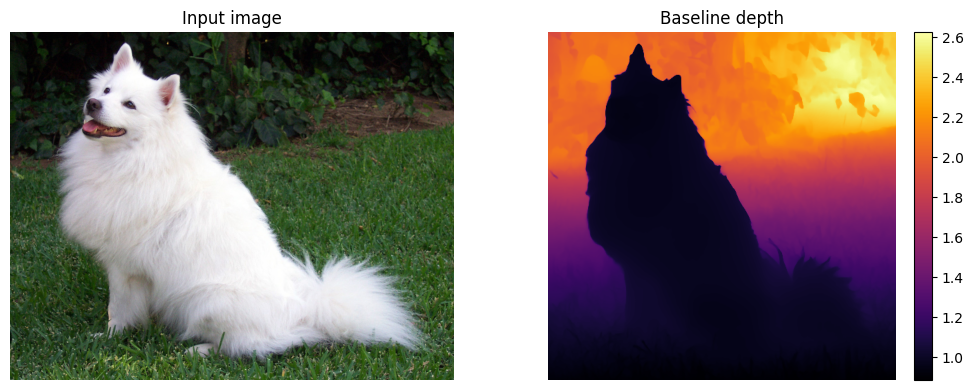

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image as _PILImage
from torchvision import transforms as T
from urllib.request import urlopen
import io as _io

# Download a real test image (GitHub-hosted)
_IMG_URL = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
try:
    _resp = urlopen(_IMG_URL, timeout=15)
    SANITY_IMG = _PILImage.open(_io.BytesIO(_resp.read())).convert("RGB")
    print(f"Downloaded test image: {SANITY_IMG.size}")
except Exception:
    print("Image download failed — using synthetic test image")
    SANITY_IMG = _PILImage.fromarray(
        np.random.default_rng(42).integers(0, 255, (256, 256, 3), dtype=np.uint8)
    )

# Prepare real image as model input
_sanity_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
SANITY_INPUT = _sanity_transform(SANITY_IMG).unsqueeze(0).unsqueeze(0).to(device)
# shape: (1, 1, 3, 504, 504)

with torch.no_grad():
    SANITY_DEPTH_REF = model(SANITY_INPUT)

# ── Show the input image and baseline depth ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(SANITY_IMG)
axes[0].set_title("Input image")
axes[0].axis("off")

depth_np = SANITY_DEPTH_REF[0, 0].cpu().numpy()
print(f"Depth range: [{depth_np.min():.4f}, {depth_np.max():.4f}]")
im = axes[1].imshow(depth_np, cmap="inferno")
axes[1].set_title("Baseline depth")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
plt.close(fig)

## GPU warmup

GPUs start in a low-power state with throttled clocks. We run 50 forward passes
to force clocks up and stabilize cuDNN plan caches before any timing begins.
`bench()` also runs 10 untimed iterations before each timed section.

In [5]:
print("Warming up GPU...")
with torch.no_grad():
    for _ in range(50):
        _ = model(dummy_input)
torch.cuda.synchronize()
print("GPU warm — clocks boosted and stable.")

Warming up GPU...
GPU warm — clocks boosted and stable.


## Benchmarking utilities

Every method gets timed the same way: `torch.utils.benchmark.Timer` with
`blocked_autorange`, repeated for `N_ROUNDS` independent rounds. We report
the **median of medians**.

Key helpers:
- **`bench()`** — timing with GPU clock warmup + 5 rounds of `blocked_autorange`
- **`sanity_check()`** — compare depth map vs baseline; show side-by-side on failure
- **`fresh_model()`** — clean model copy so no optimization leaks between cells
- **`reset_backends()`** — disable all global toggles (TF32, cudnn.benchmark, etc.)

In [6]:
#collapse-hide
import time
from contextlib import contextmanager
from statistics import median
import torch.utils.benchmark as _bench_mod

# ── Shared state ─────────────────────────────────────────────────────────
GPU_RESULTS: dict[str, float] = {}
SETUP_TIMES: dict[str, float] = {}
MIN_RUN_TIME: float = 3.0
N_ROUNDS: int = 5

# Cache base model weights for fresh_model()
_BASE_STATE_DICT = {k: v.cpu().clone() for k, v in model.state_dict().items()}


def reset_backends() -> None:
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


_TORCH_COMPILE_OK: bool | None = None

def _check_compile_support() -> bool:
    global _TORCH_COMPILE_OK
    if _TORCH_COMPILE_OK is not None:
        return _TORCH_COMPILE_OK
    try:
        _m = torch.compile(torch.nn.Linear(1, 1).to(device), mode="default")
        with torch.no_grad():
            _m(torch.randn(1, 1, device=device))
        _TORCH_COMPILE_OK = True
    except Exception:
        _TORCH_COMPILE_OK = False
    return _TORCH_COMPILE_OK


def check_output(name, output, reference, atol=0.05):
    if isinstance(output, np.ndarray):
        diff = float(np.max(np.abs(output - reference.cpu().numpy())))
    else:
        diff = (output.float().cpu() - reference.cpu()).abs().max().item()
    status = "OK" if diff < atol else "WARN"
    print(f"  [{status}] {name}: max diff = {diff:.6f} (atol={atol})")


def _gpu_warmup(stmt, globals_dict, n=10):
    t = _bench_mod.Timer(stmt=stmt, globals=globals_dict)
    t.timeit(n)


def bench(label, stmt, globals_dict, results=None,
          min_run_time=MIN_RUN_TIME, n_rounds=N_ROUNDS, sanity=True):
    if results is None:
        results = GPU_RESULTS

    _gpu_warmup(stmt, globals_dict)

    t = _bench_mod.Timer(stmt=stmt, globals=globals_dict, label=label)
    round_medians = []
    for _ in range(n_rounds):
        m = t.blocked_autorange(min_run_time=min_run_time)
        round_medians.append(m.median * 1e3)
    ms = median(round_medians)
    results[label] = ms
    spread = max(round_medians) - min(round_medians)
    print(f"  {label}: {ms:.3f} ms  "
          f"(spread: {spread:.3f} ms  "
          f"rounds: {', '.join(f'{r:.2f}' for r in round_medians)})")

    if sanity and SANITY_INPUT is not None:
        _mdl = globals_dict.get("model")
        if _mdl is not None and isinstance(_mdl, nn.Module):
            try:
                _dtype = None
                _ac = None
                try:
                    _fp = next(_mdl.parameters())
                    if _fp.dtype == torch.float16:
                        _dtype = torch.float16
                except StopIteration:
                    pass
                if "autocast" in stmt and "float16" in stmt:
                    _ac = torch.float16
                    _dtype = None
                elif "autocast" in stmt and "bfloat16" in stmt:
                    _ac = torch.bfloat16
                    _dtype = None
                sanity_check(label, _mdl, input_dtype=_dtype, autocast_dtype=_ac)
            except Exception as e:
                print(f"  ⚠ Sanity skip: {type(e).__name__}: {e}")


@contextmanager
def timed(label):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    yield
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    SETUP_TIMES[label] = elapsed
    print(f"  [{label}] setup: {elapsed:.2f} s")


def fresh_model() -> nn.Module:
    """Return a fresh DA3 depth model with cached weights."""
    _api = DepthAnything3(model_name=MODEL_NAME)
    m = DA3Depth(_api)
    m.load_state_dict(_BASE_STATE_DICT, strict=True)
    return m.to(device).eval()


def cleanup():
    torch._dynamo.reset()
    gc.collect()
    torch.cuda.empty_cache()


def sanity_check(name, model_or_out, *, input_dtype=None, autocast_dtype=None,
                 atol_mse=0.5):
    """Compare depth output to baseline on real image.  Show visual on failure."""
    if isinstance(model_or_out, (torch.Tensor, np.ndarray)):
        out = torch.as_tensor(model_or_out).float()
    else:
        inp = SANITY_INPUT
        if input_dtype is not None:
            inp = inp.to(dtype=input_dtype)
        with torch.no_grad():
            if autocast_dtype is not None:
                with torch.amp.autocast("cuda", dtype=autocast_dtype):
                    out = model_or_out(inp)
            else:
                out = model_or_out(inp)
        out = out.float()

    ref = SANITY_DEPTH_REF.float()
    mse = ((out.cpu() - ref.cpu()) ** 2).mean().item()

    if mse < atol_mse:
        print(f"  ✓ Sanity ({name}): depth MSE = {mse:.6f}")
    elif mse < 5.0:
        print(f"  ⚠ Sanity ({name}): depth MSE = {mse:.6f}  (above {atol_mse} threshold)")
    else:
        print(f"  ✗ Sanity ({name}): depth MSE = {mse:.6f}  — DEPTH DIVERGED")
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(SANITY_IMG)
        axes[0].set_title("Input")
        axes[0].axis("off")
        axes[1].imshow(ref[0, 0].cpu().numpy(), cmap="inferno")
        axes[1].set_title("Baseline depth")
        axes[1].axis("off")
        axes[2].imshow(out[0, 0].cpu().numpy(), cmap="inferno")
        axes[2].set_title(f"{name} depth")
        axes[2].axis("off")
        plt.tight_layout()
        plt.show()
        plt.close(fig)


print("Ready.")

Ready.


---
## 0 – Baseline (eager)

All extras disabled: no TF32, no cudnn.benchmark, no compilation. Pure eager
PyTorch with `torch.no_grad()`. This is our reference point.

In [7]:
reset_backends()

with torch.no_grad():
    _out = model(dummy_input)
print(f"Baseline output shape: {_out.shape}")

bench("0 - Baseline (eager)",
      "with torch.no_grad(): model(x)",
      {"model": model, "x": dummy_input})

Baseline output shape: torch.Size([1, 1, 504, 504])
  0 - Baseline (eager): 121.268 ms  (spread: 0.310 ms  rounds: 121.11, 121.32, 121.25, 121.42, 121.27)
  ✓ Sanity (0 - Baseline (eager)): depth MSE = 0.000000


---
## 1 – cudnn.benchmark

Auto-tune cuDNN convolution algorithms. Mostly helps CNNs; the DA3
depth head has a few convs so there's a small benefit.

In [8]:
reset_backends()
torch.backends.cudnn.benchmark = True

bench("1 - cudnn.benchmark",
      "with torch.no_grad(): model(x)",
      {"model": model, "x": dummy_input})
reset_backends()

  1 - cudnn.benchmark: 121.334 ms  (spread: 0.284 ms  rounds: 121.21, 121.33, 121.37, 121.49, 121.33)
  ✓ Sanity (1 - cudnn.benchmark): depth MSE = 0.000000


---
## 2 – channels_last

NHWC memory layout. Helps cuDNN conv kernels on Tensor-Core GPUs.
ViTs are mostly linear layers, so the gain is limited to the DPT head's
convolutions and the patch embedding.

In [9]:
reset_backends()

_m = fresh_model()
# channels_last only applies to 4D tensors; DA3 input is 5D.
_m = _m.to(memory_format=torch.channels_last)


bench("2 - channels_last",
      "with torch.no_grad(): model(x)",
      {"model": _m, "x": dummy_input})
cleanup()

[INFO ] using MLP layer as FFN
  2 - channels_last: 124.112 ms  (spread: 0.217 ms  rounds: 123.93, 123.96, 124.11, 124.12, 124.14)
  ✓ Sanity (2 - channels_last): depth MSE = 0.000000


---
## 3 – inference_mode

Stricter than `no_grad`: also disables autograd version counters
and view tracking. A few percent faster, zero accuracy cost.

In [10]:
reset_backends()

bench("3 - inference_mode",
      "with torch.inference_mode(): model(x)",
      {"model": model, "x": dummy_input})

  3 - inference_mode: 121.550 ms  (spread: 0.188 ms  rounds: 121.41, 121.56, 121.44, 121.55, 121.59)
  ✓ Sanity (3 - inference_mode): depth MSE = 0.000000


---
## 4 – TF32 matmul

On Ampere+ GPUs, TF32 rounds float32 mantissa from 23 to 10 bits
before the hardware tensor core matmul. ~2× faster for free.
On V100 (SM 7.0) this is a **no-op**.

In [11]:
reset_backends()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

bench("4 - TF32 matmul",
      "with torch.no_grad(): model(x)",
      {"model": model, "x": dummy_input})
reset_backends()

  4 - TF32 matmul: 121.577 ms  (spread: 0.741 ms  rounds: 121.26, 121.43, 121.58, 121.63, 122.00)
  ✓ Sanity (4 - TF32 matmul): depth MSE = 0.000000


---
## 5 – AMP FP16

Autocast to half precision. V100 Tensor Cores do FP16 × FP16 → FP32
accumulation. This is usually the single biggest easy win.

In [12]:
reset_backends()

bench("5 - AMP FP16",
      "with torch.no_grad():\n"
      "  with torch.amp.autocast('cuda', dtype=torch.float16):\n"
      "    model(x)",
      {"model": model, "x": dummy_input})

  5 - AMP FP16: 59.096 ms  (spread: 0.056 ms  rounds: 59.13, 59.09, 59.14, 59.09, 59.10)
  ✓ Sanity (5 - AMP FP16): depth MSE = 0.000000


---
## 6 – AMP BF16

BFloat16 has the same exponent range as FP32 (no overflow issues) but
less precision. Requires **Ampere+** Tensor Cores. On V100 this falls
back to FP32.

In [13]:
reset_backends()

if not torch.cuda.is_bf16_supported():
    print("BF16 not supported on this GPU — skipping")
    GPU_RESULTS["6 - AMP BF16"] = float("nan")
else:
    bench("6 - AMP BF16",
          "with torch.no_grad():\n"
          "  with torch.amp.autocast('cuda', dtype=torch.bfloat16):\n"
          "    model(x)",
          {"model": model, "x": dummy_input})

  6 - AMP BF16: 195.730 ms  (spread: 0.113 ms  rounds: 195.66, 195.76, 195.73, 195.77, 195.73)
  ✓ Sanity (6 - AMP BF16): depth MSE = 0.000000


---
## 7 – Static FP16 (model.half())

Convert all model weights to FP16 permanently. No autocast overhead
per forward pass, but less precision control than AMP.

In [14]:
reset_backends()

_m = fresh_model().half()
_x = dummy_input.half()

with torch.no_grad():
    _out = _m(_x)
check_output("static fp16", _out, baseline_output, atol=0.5)

bench("7 - Static FP16",
      "with torch.no_grad(): model(x)",
      {"model": _m, "x": dummy_input})
cleanup()

[INFO ] using MLP layer as FFN
  [OK] static fp16: max diff = 0.000285 (atol=0.5)


RuntimeError: Input type (float) and bias type (c10::Half) should be the same

---
## 7b – SDPA backends

PyTorch's `scaled_dot_product_attention` dispatches to FlashAttention,
Memory-Efficient, or Math backends. We test each one. DinoV2's attention
already uses SDPA, so this shows which backend the GPU selects.

In [15]:
reset_backends()

import torch.nn.functional as _F
_sdpa_backends = {
    "Flash": torch.backends.cuda.flash_sdp_enabled,
    "MemEfficient": torch.backends.cuda.mem_efficient_sdp_enabled,
    "Math": torch.backends.cuda.math_sdp_enabled,
}
print(f"SDPA backends: { {k: v() for k, v in _sdpa_backends.items()} }")

for backend_name, ctx_mgrs in [
    ("flash", (torch.backends.cuda.sdp_kernel(enable_flash=True, enable_mem_efficient=False, enable_math=False),)),
    ("mem_efficient", (torch.backends.cuda.sdp_kernel(enable_flash=False, enable_mem_efficient=True, enable_math=False),)),
    ("math", (torch.backends.cuda.sdp_kernel(enable_flash=False, enable_mem_efficient=False, enable_math=True),)),
]:
    try:
        with ctx_mgrs[0]:
            with torch.no_grad():
                _ = model(dummy_input)
        with ctx_mgrs[0]:
            bench(f"7b - SDPA ({backend_name})",
                  "with torch.no_grad(): model(x)",
                  {"model": model, "x": dummy_input})
    except Exception as e:
        print(f"  SDPA {backend_name}: {type(e).__name__} — {e}")
        GPU_RESULTS[f"7b - SDPA ({backend_name})"] = float("nan")

SDPA backends: {'Flash': True, 'MemEfficient': True, 'Math': True}
  SDPA flash: RuntimeError — No available kernel. Aborting execution.
  SDPA mem_efficient: AttributeError — '_GeneratorContextManager' object has no attribute 'args'
  SDPA math: AttributeError — '_GeneratorContextManager' object has no attribute 'args'


---
## 8 – torch.compile (default)

Fast compile, good speed. Best compile-time / run-time trade-off.
Requires Triton (Linux only).

In [16]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["8 - compile (default)"] = float("nan")
else:
    _m = fresh_model()
    with timed("compile default"):
        _m = torch.compile(_m, mode="default")
        with torch.no_grad():
            _ = _m(dummy_input)  # trigger compilation

    bench("8 - compile (default)",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
    cleanup()

[INFO ] using MLP layer as FFN
  [compile default] setup: 31.99 s
  8 - compile (default): 115.671 ms  (spread: 0.918 ms  rounds: 115.85, 115.74, 115.67, 114.93, 114.98)
  ✓ Sanity (8 - compile (default)): depth MSE = 0.000000


---
## 9 – torch.compile (reduce-overhead)

Uses CUDA Graphs internally — best for batch=1.
Requires Triton (Linux only).

In [17]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["9 - compile (reduce-overhead)"] = float("nan")
else:
    _m = fresh_model()
    with timed("compile reduce-overhead"):
        _m = torch.compile(_m, mode="reduce-overhead")
        with torch.no_grad():
            _ = _m(dummy_input)  # trigger compilation

    bench("9 - compile (reduce-overhead)",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
    cleanup()

[INFO ] using MLP layer as FFN
  [compile reduce-overhead] setup: 18.62 s
  9 - compile (reduce-overhead): 115.741 ms  (spread: 1.701 ms  rounds: 116.22, 116.48, 115.74, 115.28, 114.78)
  ✓ Sanity (9 - compile (reduce-overhead)): depth MSE = 0.000000


---
## 10 – torch.compile (max-autotune)

Slowest compile; tries more kernel variants.
Requires Triton (Linux only).

In [18]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["10 - compile (max-autotune)"] = float("nan")
else:
    _m = fresh_model()
    with timed("compile max-autotune"):
        _m = torch.compile(_m, mode="max-autotune")
        with torch.no_grad():
            _ = _m(dummy_input)  # trigger compilation

    bench("10 - compile (max-autotune)",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
    cleanup()

[INFO ] using MLP layer as FFN


AUTOTUNE mm(1297x1024, 1024x4096)
  mm 1.0240 ms 100.0% 
  triton_mm_54 1.2585 ms 81.4% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=64, BLOCK_N=128, B_PROLOGUE_CAST_TYPE=None, EVEN_K=True, GROUP_M=8, num_stages=3, num_warps=4
  triton_mm_63 1.3466 ms 76.0% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=64, BLOCK_M=128, BLOCK_N=128, B_PROLOGUE_CAST_TYPE=None, EVEN_K=True, GROUP_M=8, num_stages=5, num_warps=8
  triton_mm_61 1.3670 ms 74.9% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, B_PROLOGUE_CAST_TYPE=None, EVEN_K=True, GROUP_M=8, num_stages=3, num_warps=4
  triton_mm_56 1.4408 ms 71.1% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=64, BLOCK_M=64, BLOCK_N=128, B_PROLOGUE_CAST_TYPE=None, EVEN_K=True, GROUP_M=8, num_stages=3, num_warps=4
  triton_mm_58 1.4428 ms 71.0% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, B_PROLOGUE_CAST_TYPE=None, EVEN_K=True, GROUP_M=8, num_stages=3, num_warps=4
  triton_mm

  [compile max-autotune] setup: 408.97 s
  10 - compile (max-autotune): 115.686 ms  (spread: 1.504 ms  rounds: 114.54, 114.77, 115.69, 115.79, 116.05)
  ✓ Sanity (10 - compile (max-autotune)): depth MSE = 0.000000


---
## 11 – compile fullgraph + freeze

Zero graph breaks + Inductor tuning. If the model has no dynamic
control flow, the compiler can optimize the entire graph at once.

In [19]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["11 - compile fullgraph+freeze"] = float("nan")
else:
    _m = fresh_model()
    try:
        with timed("compile fullgraph"):
            _m = torch.compile(_m, mode="reduce-overhead", fullgraph=True)
            with torch.no_grad():
                _ = _m(dummy_input)

        bench("11 - compile fullgraph+freeze",
              "with torch.no_grad(): model(x)",
              {"model": _m, "x": dummy_input})
    except Exception as e:
        print(f"fullgraph compile failed (graph breaks): {e}")
        GPU_RESULTS["11 - compile fullgraph+freeze"] = float("nan")
    cleanup()

[INFO ] using MLP layer as FFN
fullgraph compile failed (graph breaks): call_function UserDefinedClassVariable(<class 'addict.addict.Dict'>) [ConstDictVariable()] {}

from user code:
   File "/tmp/ipykernel_628257/3978613543.py", line 17, in forward
    out = self.net(x, export_feat_layers=[])
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 140, in forward
    output = self._process_depth_head(feats, H, W)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 209, in _process_depth_head
    return self.head(feats, H, W, patch_start_idx=0)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/dpt.py", line 189, in forward
    return Dict(out_dict)

Set TORCH_LOGS="+dynamo" and TORCHDYNAMO_VERBOSE=1 for more information


You can suppress this exception and fall back to eager by setting:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True



---
## 12 – JIT Trace + optimize

TorchScript graph fusion via `torch.jit.trace`. Records the computation
graph and applies graph-level optimizations. May fail on models with
dynamic control flow or dict outputs.

In [20]:
reset_backends()

_m = fresh_model()
try:
    with torch.no_grad():
        _traced = torch.jit.trace(_m, dummy_input)
    _traced = torch.jit.optimize_for_inference(_traced)
    with torch.no_grad():
        _out = _traced(dummy_input)
    check_output("jit trace", _out, baseline_output, atol=0.5)
    bench("12 - JIT Trace",
          "with torch.no_grad(): model(x)",
          {"model": _traced, "x": dummy_input})
except Exception as e:
    print(f"JIT Trace failed: {type(e).__name__}: {e}")
    GPU_RESULTS["12 - JIT Trace"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] jit trace: max diff = 0.000000 (atol=0.5)
  12 - JIT Trace: 117.803 ms  (spread: 0.677 ms  rounds: 117.63, 117.80, 117.75, 118.13, 118.30)
  ✓ Sanity (12 - JIT Trace): depth MSE = 0.000000


---
## 13 – Manual CUDA Graphs

Pre-record a GPU kernel sequence and replay it with zero CPU overhead.
Best for static input shapes. Requires capturing the computation graph
in a controlled environment.

In [21]:
reset_backends()

_m = fresh_model()
_static_x = dummy_input.clone()

# Warmup for graph capture
with torch.no_grad():
    for _ in range(3):
        _ = _m(_static_x)
torch.cuda.synchronize()

# Capture graph
_graph = torch.cuda.CUDAGraph()
with torch.cuda.graph(_graph):
    _static_out = _m(_static_x)

def _replay():
    _graph.replay()
    return _static_out

# Verify
_graph.replay()
check_output("cuda graph", _static_out, baseline_output, atol=0.5)

bench("13 - CUDA Graphs",
      "graph.replay()",
      {"graph": _graph})
cleanup()

[INFO ] using MLP layer as FFN


RuntimeError: CUDA error: operation failed due to a previous error during capture
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


---
## 14 – torchao int8 weight-only

Store weights as int8, dequantize on-the-fly in the matmul kernel.
2× memory reduction. With `torch.compile` the dequant fuses into
the matmul for near-FP16 speed.

In [22]:
reset_backends()

try:
    from torchao.quantization import quantize_, int8_weight_only
    _m = fresh_model()
    quantize_(_m, int8_weight_only())
    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("torchao int8wo", _out, baseline_output, atol=1.0)

    bench("14 - torchao int8 weight-only",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
except Exception as e:
    print(f"torchao int8 weight-only failed: {e}")
    GPU_RESULTS["14 - torchao int8 weight-only"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] torchao int8wo: max diff = 0.000246 (atol=1.0)
  14 - torchao int8 weight-only: 133.572 ms  (spread: 0.307 ms  rounds: 133.37, 133.57, 133.52, 133.68, 133.65)
  ✓ Sanity (14 - torchao int8 weight-only): depth MSE = 0.000000


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 15 – torchao int8 dynamic quantization

Quantize both weights and activations to int8 dynamically.
Stronger accuracy preservation than weight-only, with potential
speedup from int8 matmul on supported hardware.

In [23]:
reset_backends()

try:
    from torchao.quantization import quantize_, int8_dynamic_activation_int8_weight
    _m = fresh_model()
    quantize_(_m, int8_dynamic_activation_int8_weight())
    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("torchao int8dyn", _out, baseline_output, atol=1.0)

    bench("15 - torchao int8 dynamic",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
except Exception as e:
    print(f"torchao int8 dynamic failed: {e}")
    GPU_RESULTS["15 - torchao int8 dynamic"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] torchao int8dyn: max diff = 0.000404 (atol=1.0)
  15 - torchao int8 dynamic: 280.999 ms  (spread: 0.298 ms  rounds: 281.19, 280.97, 281.22, 280.93, 281.00)
  ✓ Sanity (15 - torchao int8 dynamic): depth MSE = 0.000000


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 16 – torchao int4 weight-only

4-bit weight quantization via custom Triton kernels. 4× memory reduction
vs FP16. Best for memory-bound workloads.

In [24]:
reset_backends()

try:
    from torchao.quantization import quantize_, int4_weight_only
    _m = fresh_model()
    quantize_(_m, int4_weight_only())
    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("torchao int4wo", _out, baseline_output, atol=2.0)

    bench("16 - torchao int4 weight-only",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
except Exception as e:
    print(f"torchao int4 weight-only failed: {e}")
    GPU_RESULTS["16 - torchao int4 weight-only"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
torchao int4 weight-only failed: Expected Tensor argument scales to have dtype torch.bfloat16, but got torch.float32 instead.


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 17 – ONNX Runtime CUDA EP

Export to ONNX, run via ONNX Runtime with CUDA Execution Provider.
ORT applies graph-level optimizations (constant folding, op fusion).

In [25]:
reset_backends()

try:
    import onnxruntime as ort

    _m = fresh_model()

    # Export to ONNX — wrap to handle the dict-based inner forward
    with timed("ONNX export"):
        _dummy = dummy_input.cpu()
        torch.onnx.export(
            _m.cpu(), _dummy,
            "model.onnx",
            input_names=["input"],
            output_names=["depth"],
            dynamic_axes={"input": {0: "batch"}, "depth": {0: "batch"}},
            opset_version=17,
        )
    _m.to(device)

    with timed("ORT session"):
        opts = ort.SessionOptions()
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_EXTENDED
        sess = ort.InferenceSession(
            "model.onnx",
            opts,
            providers=["CUDAExecutionProvider"],
        )

    _np_input = dummy_input.cpu().numpy()
    _ort_out = sess.run(None, {"input": _np_input})[0]
    check_output("ORT CUDA", torch.tensor(_ort_out).to(device), baseline_output, atol=0.5)

    bench("17 - ONNX Runtime CUDA EP",
          "sess.run(None, {'input': np_input})",
          {"sess": sess, "np_input": _np_input},
          sanity=False)
except Exception as e:
    print(f"ORT CUDA EP failed: {type(e).__name__}: {e}")
    GPU_RESULTS["17 - ONNX Runtime CUDA EP"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
ORT CUDA EP failed: RuntimeError: CUDA error: named symbol not found
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 18 – ORT CUDA EP + IO Binding

Zero-copy GPU inference: bind CUDA tensors directly to ORT inputs/outputs
so data never leaves the GPU.

In [26]:
reset_backends()

try:
    import onnxruntime as ort

    if not os.path.exists("model.onnx"):
        print("model.onnx not found — run cell 17 first")
        GPU_RESULTS["18 - ORT CUDA EP + IO Bind"] = float("nan")
    else:
        opts = ort.SessionOptions()
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_EXTENDED
        sess = ort.InferenceSession("model.onnx", opts,
                                     providers=["CUDAExecutionProvider"])

        _io = sess.io_binding()
        _gpu_input = dummy_input.contiguous()
        _gpu_output = torch.empty_like(baseline_output)
        _io.bind_input("input", "cuda", 0, np.float32,
                        list(_gpu_input.shape),
                        _gpu_input.data_ptr())
        _io.bind_output("depth", "cuda", 0, np.float32,
                         list(_gpu_output.shape),
                         _gpu_output.data_ptr())

        sess.run_with_iobinding(_io)
        check_output("ORT IO Bind", _gpu_output, baseline_output, atol=0.5)

        bench("18 - ORT CUDA EP + IO Bind",
              "sess.run_with_iobinding(io)",
              {"sess": sess, "io": _io},
              sanity=False)
except Exception as e:
    print(f"ORT IO Binding failed: {type(e).__name__}: {e}")
    GPU_RESULTS["18 - ORT CUDA EP + IO Bind"] = float("nan")
cleanup()

ORT IO Binding failed: RuntimeError: Failed to find NodeArg with name: depth in the def list


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 19 – ORT TensorRT EP

TRT engine via ORT. Requires TensorRT libraries and **SM ≥ 8.0** (Ampere+).
On V100 (SM 7.0) this may fail.

In [27]:
reset_backends()

try:
    import onnxruntime as ort
    if "TensorrtExecutionProvider" not in ort.get_available_providers():
        print("TensorRT EP not available")
        GPU_RESULTS["19 - ORT TensorRT EP"] = float("nan")
    elif not os.path.exists("model.onnx"):
        print("model.onnx not found — run cell 17 first")
        GPU_RESULTS["19 - ORT TensorRT EP"] = float("nan")
    else:
        with timed("TRT engine build"):
            sess = ort.InferenceSession(
                "model.onnx",
                providers=["TensorrtExecutionProvider", "CUDAExecutionProvider"],
            )
        _np_in = dummy_input.cpu().numpy()
        _out = sess.run(None, {"input": _np_in})[0]
        check_output("ORT TRT", torch.tensor(_out).to(device), baseline_output, atol=1.0)
        bench("19 - ORT TensorRT EP",
              "sess.run(None, {'input': np_input})",
              {"sess": sess, "np_input": _np_in},
              sanity=False)
except Exception as e:
    print(f"ORT TensorRT EP failed: {type(e).__name__}: {e}")
    GPU_RESULTS["19 - ORT TensorRT EP"] = float("nan")
cleanup()

*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:539 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************
  [TRT engine build] setup: 1.02 s
ORT TensorRT EP failed: InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Invalid rank for input: input Got: 5 Expected: 4 Please fix either the inputs/outputs or the model.


2026-03-25 20:42:35.145683992 [E:onnxruntime:Default, provider_bridge_ort.cc:2331 TryGetProviderInfo_TensorRT] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /root/nn_inference/.venv/lib/python3.11/site-packages/onnxruntime/capi/libonnxruntime_providers_tensorrt.so with error: libnvonnxparser.so.10: cannot open shared object file: No such file or directory



RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 20 – Torch-TensorRT

Direct TRT compilation from PyTorch. Requires `torch_tensorrt` and
**SM ≥ 8.0**. On V100 this typically fails.

In [28]:
reset_backends()

try:
    import torch_tensorrt
    _m = fresh_model().half()
    _x = dummy_input.half()
    with timed("Torch-TRT compile"):
        _trt = torch_tensorrt.compile(
            _m, inputs=[torch_tensorrt.Input(shape=_x.shape, dtype=torch.float16)],
            enabled_precisions={torch.float16},
        )
    with torch.no_grad():
        _out = _trt(_x)
    check_output("Torch-TRT", _out, baseline_output, atol=1.0)
    bench("20 - Torch-TensorRT",
          "with torch.no_grad(): model(x)",
          {"model": _trt, "x": _x})
except Exception as e:
    print(f"Torch-TRT failed: {type(e).__name__}: {e}")
    GPU_RESULTS["20 - Torch-TensorRT"] = float("nan")
cleanup()

Unable to import quantization op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models


[INFO ] using MLP layer as FFN
Torch-TRT failed: Unsupported: call_function UserDefinedClassVariable(<class 'addict.addict.Dict'>) [ConstDictVariable()] {}

from user code:
   File "/tmp/ipykernel_628257/3978613543.py", line 17, in forward
    out = self.net(x, export_feat_layers=[])
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 140, in forward
    output = self._process_depth_head(feats, H, W)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 209, in _process_depth_head
    return self.head(feats, H, W, patch_start_idx=0)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
  File "/root/nn_inference/.venv/lib/python3.11/site-pa

RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 21 – Triton fused softmax

Replace the attention softmax in every transformer block with a custom
Triton kernel. Reduces memory traffic by fusing the softmax into a
single kernel launch.

In [29]:
reset_backends()

try:
    import triton
    import triton.language as tl

    @triton.jit
    def _fused_softmax_kernel(output_ptr, input_ptr, n_cols, BLOCK: tl.constexpr):
        row = tl.program_id(0)
        offsets = tl.arange(0, BLOCK)
        mask = offsets < n_cols
        inp = tl.load(input_ptr + row * n_cols + offsets, mask=mask, other=-float("inf"))
        row_max = tl.max(inp, axis=0)
        safe = inp - row_max
        num = tl.exp(safe)
        den = tl.sum(num, axis=0)
        out = num / den
        tl.store(output_ptr + row * n_cols + offsets, out, mask=mask)

    class _TritonSoftmax(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            n_cols = x.shape[-1]
            BLOCK = triton.next_power_of_2(n_cols)
            out = torch.empty_like(x)
            _fused_softmax_kernel[(x.numel() // n_cols,)](out, x, n_cols, BLOCK=BLOCK)
            return out

    def _triton_softmax(x, dim=-1):
        if dim != -1 and dim != x.ndim - 1:
            return torch.nn.functional.softmax(x, dim=dim)
        return _TritonSoftmax.apply(x)

    _m = fresh_model()
    # Patch DinoV2 attention blocks
    _patched = 0
    for module in _m.modules():
        if hasattr(module, "attn_drop") and hasattr(module, "qkv"):
            _orig_forward = module.forward
            def _make_patched(mod, orig_fwd):
                def _fwd(x):
                    B, N, C = x.shape
                    qkv = mod.qkv(x).reshape(B, N, 3, mod.num_heads, C // mod.num_heads).permute(2, 0, 3, 1, 4)
                    q, k, v = qkv.unbind(0)
                    scale = (C // mod.num_heads) ** -0.5
                    attn = (q @ k.transpose(-2, -1)) * scale
                    attn = _triton_softmax(attn, dim=-1)
                    x = (attn @ v).transpose(1, 2).reshape(B, N, C)
                    x = mod.proj(x)
                    drop = mod.proj_drop if hasattr(mod, 'proj_drop') else None
                    if drop is not None and isinstance(drop, nn.Module):
                        x = drop(x)
                    elif drop is not None and isinstance(drop, float) and drop > 0:
                        x = F.dropout(x, p=drop, training=mod.training)
                    return x
                return _fwd
            module.forward = _make_patched(module, _orig_forward)
            _patched += 1

    print(f"Patched {_patched} attention blocks with Triton softmax")
    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("triton softmax", _out, baseline_output, atol=0.5)

    bench("21 - Triton fused softmax",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
except Exception as e:
    print(f"Triton fused softmax failed: {type(e).__name__}: {e}")
    GPU_RESULTS["21 - Triton fused softmax"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
Patched 24 attention blocks with Triton softmax
Triton fused softmax failed: TypeError: _make_patched.<locals>._fwd() got an unexpected keyword argument 'pos'


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 22 – compile fullgraph + FP16

Combine `torch.compile(fullgraph=True)` with FP16 for maximum
compiler optimization on half-precision model.

In [30]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["22 - compile fullgraph+FP16"] = float("nan")
else:
    _m = fresh_model().half()
    _x = dummy_input.half()
    try:
        with timed("compile fullgraph+FP16"):
            _m = torch.compile(_m, mode="reduce-overhead", fullgraph=True)
            with torch.no_grad():
                _ = _m(_x)
        bench("22 - compile fullgraph+FP16",
              "with torch.no_grad(): model(x)",
              {"model": _m, "x": dummy_input})
    except Exception as e:
        print(f"compile fullgraph+FP16 failed: {e}")
        GPU_RESULTS["22 - compile fullgraph+FP16"] = float("nan")
    cleanup()

[INFO ] using MLP layer as FFN
compile fullgraph+FP16 failed: call_function UserDefinedClassVariable(<class 'addict.addict.Dict'>) [ConstDictVariable()] {}

from user code:
   File "/tmp/ipykernel_628257/3978613543.py", line 17, in forward
    out = self.net(x, export_feat_layers=[])
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 140, in forward
    output = self._process_depth_head(feats, H, W)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 209, in _process_depth_head
    return self.head(feats, H, W, patch_start_idx=0)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/dpt.py", line 189, in forward
    return Dict(out_dict)

Set TORCH_LOGS="+dynamo" and TORCHDYNAMO_VERBOSE=1 for more information


You can suppress this exception and fall back to eager by setting:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True



RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 23 – Weight pruning 50 %

Unstructured L1 pruning: set 50 % of weights to zero per layer.
On V100 there's no hardware sparse tensor core support, so the
dense matmul kernels still process every element.

In [31]:
reset_backends()
import torch.nn.utils.prune as prune

_m = fresh_model()
for name, module in _m.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        prune.l1_unstructured(module, name="weight", amount=0.5)
        prune.remove(module, "weight")

_nonzero = sum((p == 0).sum().item() for p in _m.parameters())
_total = sum(p.numel() for p in _m.parameters())
print(f"Sparsity: {_nonzero/_total*100:.1f}% zeros")

with torch.no_grad():
    _out = _m(dummy_input)
check_output("pruned 50%", _out, baseline_output, atol=2.0)

bench("23 - Pruning 50%",
      "with torch.no_grad(): model(x)",
      {"model": _m, "x": dummy_input})
cleanup()

[INFO ] using MLP layer as FFN
Sparsity: 49.9% zeros
  [OK] pruned 50%: max diff = 0.031654 (atol=2.0)
  23 - Pruning 50%: 119.957 ms  (spread: 0.260 ms  rounds: 119.84, 119.96, 119.90, 120.05, 120.10)
  ✓ Sanity (23 - Pruning 50%): depth MSE = 0.000407


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 24 – Weight pruning 50 % + compile

Pruned model + `torch.compile`. The compiler might exploit sparsity
patterns for better kernel selection.

In [32]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["24 - Pruning 50% + compile"] = float("nan")
else:
    import torch.nn.utils.prune as prune
    _m = fresh_model()
    for name, module in _m.named_modules():
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            prune.l1_unstructured(module, name="weight", amount=0.5)
            prune.remove(module, "weight")

    with timed("compile pruned"):
        _m = torch.compile(_m, mode="reduce-overhead")
        with torch.no_grad():
            _ = _m(dummy_input)

    bench("24 - Pruning 50% + compile",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
    cleanup()

[INFO ] using MLP layer as FFN


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 25 – torch.export + AOTInductor

Ahead-of-time compiled `.so` artifact via `torch.export` + AOTInductor.
Produces a standalone shared library that can be loaded without Python.

In [33]:
reset_backends()

try:
    _m = fresh_model()
    with timed("export + aot"):
        ep = torch.export.export(_m, (dummy_input,))
        so_path = torch._inductor.aot_compile(ep.module(), (dummy_input,))
    print(f"AOT artifact: {so_path}")

    _aot = torch._export.aot_load(so_path, device=str(device))
    with torch.no_grad():
        _out = _aot(dummy_input)
    check_output("AOTInductor", _out, baseline_output, atol=0.5)

    bench("25 - AOTInductor",
          "model(x)",
          {"model": _aot, "x": dummy_input},
          sanity=False)
except Exception as e:
    print(f"AOTInductor failed: {type(e).__name__}: {e}")
    GPU_RESULTS["25 - AOTInductor"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
AOTInductor failed: Unsupported: call_function UserDefinedClassVariable(<class 'addict.addict.Dict'>) [ConstDictVariable()] {}

from user code:
   File "/tmp/ipykernel_628257/3978613543.py", line 17, in forward
    out = self.net(x, export_feat_layers=[])
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 140, in forward
    output = self._process_depth_head(feats, H, W)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/depth_anything_3/model/da3.py", line 209, in _process_depth_head
    return self.head(feats, H, W, patch_start_idx=0)
  File "/root/nn_inference/.venv/lib/python3.11/site-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
  File "/root/nn_inference/.venv/lib/python3.11/site-

RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 26 – Multi-stream pipelining

Split a batch across CUDA streams. At batch=1 there's nothing to split,
so we test with batch=4 to show the concept.

In [34]:
reset_backends()

# Multi-stream only makes sense with batch>1
_MULTI_BATCH = 4
_multi_x = torch.randn(_MULTI_BATCH, 1, 3, IMG_SIZE, IMG_SIZE, device=device)

N_STREAMS = 2
streams = [torch.cuda.Stream() for _ in range(N_STREAMS)]

_m = fresh_model()

def _multi_stream_infer():
    chunks = _multi_x.chunk(N_STREAMS, dim=0)
    outs = [None] * N_STREAMS
    for i, (chunk, stream) in enumerate(zip(chunks, streams)):
        with torch.cuda.stream(stream):
            with torch.no_grad():
                outs[i] = _m(chunk)
    torch.cuda.synchronize()
    return torch.cat(outs, dim=0)

_out = _multi_stream_infer()
print(f"Multi-stream output: {_out.shape}")

bench("26 - Multi-stream (batch={})".format(_MULTI_BATCH),
      "fn()",
      {"fn": _multi_stream_infer})
cleanup()

RuntimeError: Offset increment outside graph capture encountered unexpectedly.

---
## 27 – bitsandbytes int8 (LLM.int8())

Mixed-precision decomposition: outlier features go through FP16,
the rest through int8. From Dettmers et al. (2022).

In [35]:
reset_backends()

try:
    import bitsandbytes as bnb

    _m = fresh_model()
    # Replace Linear layers with bnb.nn.Linear8bitLt
    def _replace_with_bnb_int8(module):
        for name, child in module.named_children():
            if isinstance(child, nn.Linear):
                has_bias = child.bias is not None
                new = bnb.nn.Linear8bitLt(
                    child.in_features, child.out_features,
                    bias=has_bias, has_fp16_weights=False, threshold=6.0,
                )
                new.weight = bnb.nn.Int8Params(
                    child.weight.data, requires_grad=False, has_fp16_weights=False,
                )
                if has_bias:
                    new.bias = nn.Parameter(child.bias.data)
                setattr(module, name, new.to(device))
            else:
                _replace_with_bnb_int8(child)

    _replace_with_bnb_int8(_m)
    _m = _m.to(device).eval()

    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("bnb int8", _out, baseline_output, atol=2.0)

    bench("27 - bitsandbytes int8",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
except Exception as e:
    print(f"bitsandbytes int8 failed: {type(e).__name__}: {e}")
    GPU_RESULTS["27 - bitsandbytes int8"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] bnb int8: max diff = 0.000437 (atol=2.0)
  27 - bitsandbytes int8: 132.004 ms  (spread: 0.265 ms  rounds: 132.22, 132.04, 131.99, 131.95, 132.00)
  ✓ Sanity (27 - bitsandbytes int8): depth MSE = 0.000000


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 28 – bitsandbytes NF4

4-bit NormalFloat from QLoRA. Saves 8× memory vs FP32 but the dequant
kernel adds overhead per matmul.

In [36]:
reset_backends()

try:
    import bitsandbytes as bnb

    _m = fresh_model()
    def _replace_with_bnb_nf4(module):
        for name, child in module.named_children():
            if isinstance(child, nn.Linear):
                has_bias = child.bias is not None
                new = bnb.nn.LinearNF4(
                    child.in_features, child.out_features, bias=has_bias,
                )
                new.weight = bnb.nn.Params4bit(
                    child.weight.data, requires_grad=False,
                    quant_type="nf4", blocksize=64,
                )
                if has_bias:
                    new.bias = nn.Parameter(child.bias.data)
                setattr(module, name, new.to(device))
            else:
                _replace_with_bnb_nf4(child)

    _replace_with_bnb_nf4(_m)
    _m = _m.to(device).eval()

    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("bnb nf4", _out, baseline_output, atol=5.0)

    bench("28 - bitsandbytes NF4",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
except Exception as e:
    print(f"bitsandbytes NF4 failed: {type(e).__name__}: {e}")
    GPU_RESULTS["28 - bitsandbytes NF4"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] bnb nf4: max diff = 0.004701 (atol=5.0)
  28 - bitsandbytes NF4: 123.685 ms  (spread: 0.053 ms  rounds: 123.67, 123.66, 123.71, 123.69, 123.71)
  ✓ Sanity (28 - bitsandbytes NF4): depth MSE = 0.000003


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 29 – FP16 + compile reduce-overhead

The "GPT, Fast" recipe: half-precision model + `torch.compile` with
`reduce-overhead` mode (internal CUDA Graphs).

In [37]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["29 - FP16 + compile reduce-overhead"] = float("nan")
else:
    _m = fresh_model().half()
    _x = dummy_input.half()
    with timed("compile FP16+r-o"):
        _m = torch.compile(_m, mode="reduce-overhead")
        with torch.no_grad():
            _ = _m(_x)

    bench("29 - FP16 + compile reduce-overhead",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
    cleanup()

[INFO ] using MLP layer as FFN


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 30 – FP16 + TF32 + cudnn.benchmark

The simplest no-compile combo: just flip switches and call `.half()`.
Anyone can do this in two lines of code.

In [38]:
reset_backends()
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

_m = fresh_model().half()
_x = dummy_input.half()

with torch.inference_mode():
    _out = _m(_x)
check_output("fp16+tf32+cudnn", _out, baseline_output, atol=0.5)

bench("30 - FP16 + TF32 + cudnn.benchmark",
      "with torch.inference_mode(): model(x)",
      {"model": _m, "x": dummy_input})
cleanup()

[INFO ] using MLP layer as FFN


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## 31 – FP16 + compile reduce-overhead + TF32

The strongest combo: half precision + TF32 matmul + `torch.compile`
with reduce-overhead mode (internal CUDA Graphs).

In [39]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported — skipping")
    GPU_RESULTS["31 - FP16 + compile r-o + TF32"] = float("nan")
else:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

    _m = fresh_model().half()
    _x = dummy_input.half()
    with timed("compile FP16+r-o+TF32"):
        _m = torch.compile(_m, mode="reduce-overhead")
        with torch.no_grad():
            _ = _m(_x)

    bench("31 - FP16 + compile r-o + TF32",
          "with torch.no_grad(): model(x)",
          {"model": _m, "x": dummy_input})
    cleanup()

[INFO ] using MLP layer as FFN


RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## Profiler deep-dive

Kernel-level breakdown of where time goes in the baseline model.

In [40]:
try:
    torch.cuda.synchronize()
except RuntimeError:
    pass
gc.collect()
torch.cuda.empty_cache()

prof_model = fresh_model()
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    profile_memory=True,
    with_flops=True,
) as prof:
    with torch.no_grad():
        for _ in range(10):
            prof_model(dummy_input)

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))
cleanup()

RuntimeError: captures_underway.empty() INTERNAL ASSERT FAILED at "../c10/cuda/CUDACachingAllocator.cpp":2967, please report a bug to PyTorch. 

---
## Results (batch=1)

All GPU methods ranked by latency. Green = faster than baseline, red = slower.
N/A = requires Docker / specific hardware.

In [41]:
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage


def _print_table(results, baseline_key):
    bl = results.get(baseline_key, 1.0)
    print(f"{'Method':<48} {'ms':>8}  {'Speedup':>8}")
    print("-" * 68)
    for name, ms in sorted(results.items(), key=lambda kv: kv[1] if kv[1] == kv[1] else 1e9):
        if ms != ms:
            print(f"{name:<48} {'N/A':>8}  {'N/A':>8}")
        else:
            arrow = "  <-- baseline" if name == baseline_key else ""
            print(f"{name:<48} {ms:>7.3f}   {bl / ms:>7.2f}x{arrow}")
    print()


print(f"=== GPU batch={BATCH} | model=DA3 {MODEL_NAME} | {N_ROUNDS} rounds / median of medians ===\n")
_print_table(GPU_RESULTS, "0 - Baseline (eager)")

if SETUP_TIMES:
    print("=== One-time setup / conversion costs ===")
    print(f"{'Step':<48} {'seconds':>8}")
    print("-" * 58)
    for name, s in SETUP_TIMES.items():
        print(f"{name:<48} {s:>7.2f}s")
    print()

=== GPU batch=1 | model=DA3 da3metric-large | 5 rounds / median of medians ===

Method                                                 ms   Speedup
--------------------------------------------------------------------
5 - AMP FP16                                      59.096      2.05x
8 - compile (default)                            115.671      1.05x
10 - compile (max-autotune)                      115.686      1.05x
9 - compile (reduce-overhead)                    115.741      1.05x
12 - JIT Trace                                   117.803      1.03x
23 - Pruning 50%                                 119.957      1.01x
0 - Baseline (eager)                             121.268      1.00x  <-- baseline
1 - cudnn.benchmark                              121.334      1.00x
3 - inference_mode                               121.550      1.00x
4 - TF32 matmul                                  121.577      1.00x
28 - bitsandbytes NF4                            123.685      0.98x
2 - channels_last    

Saved inference_benchmark_gpu.png


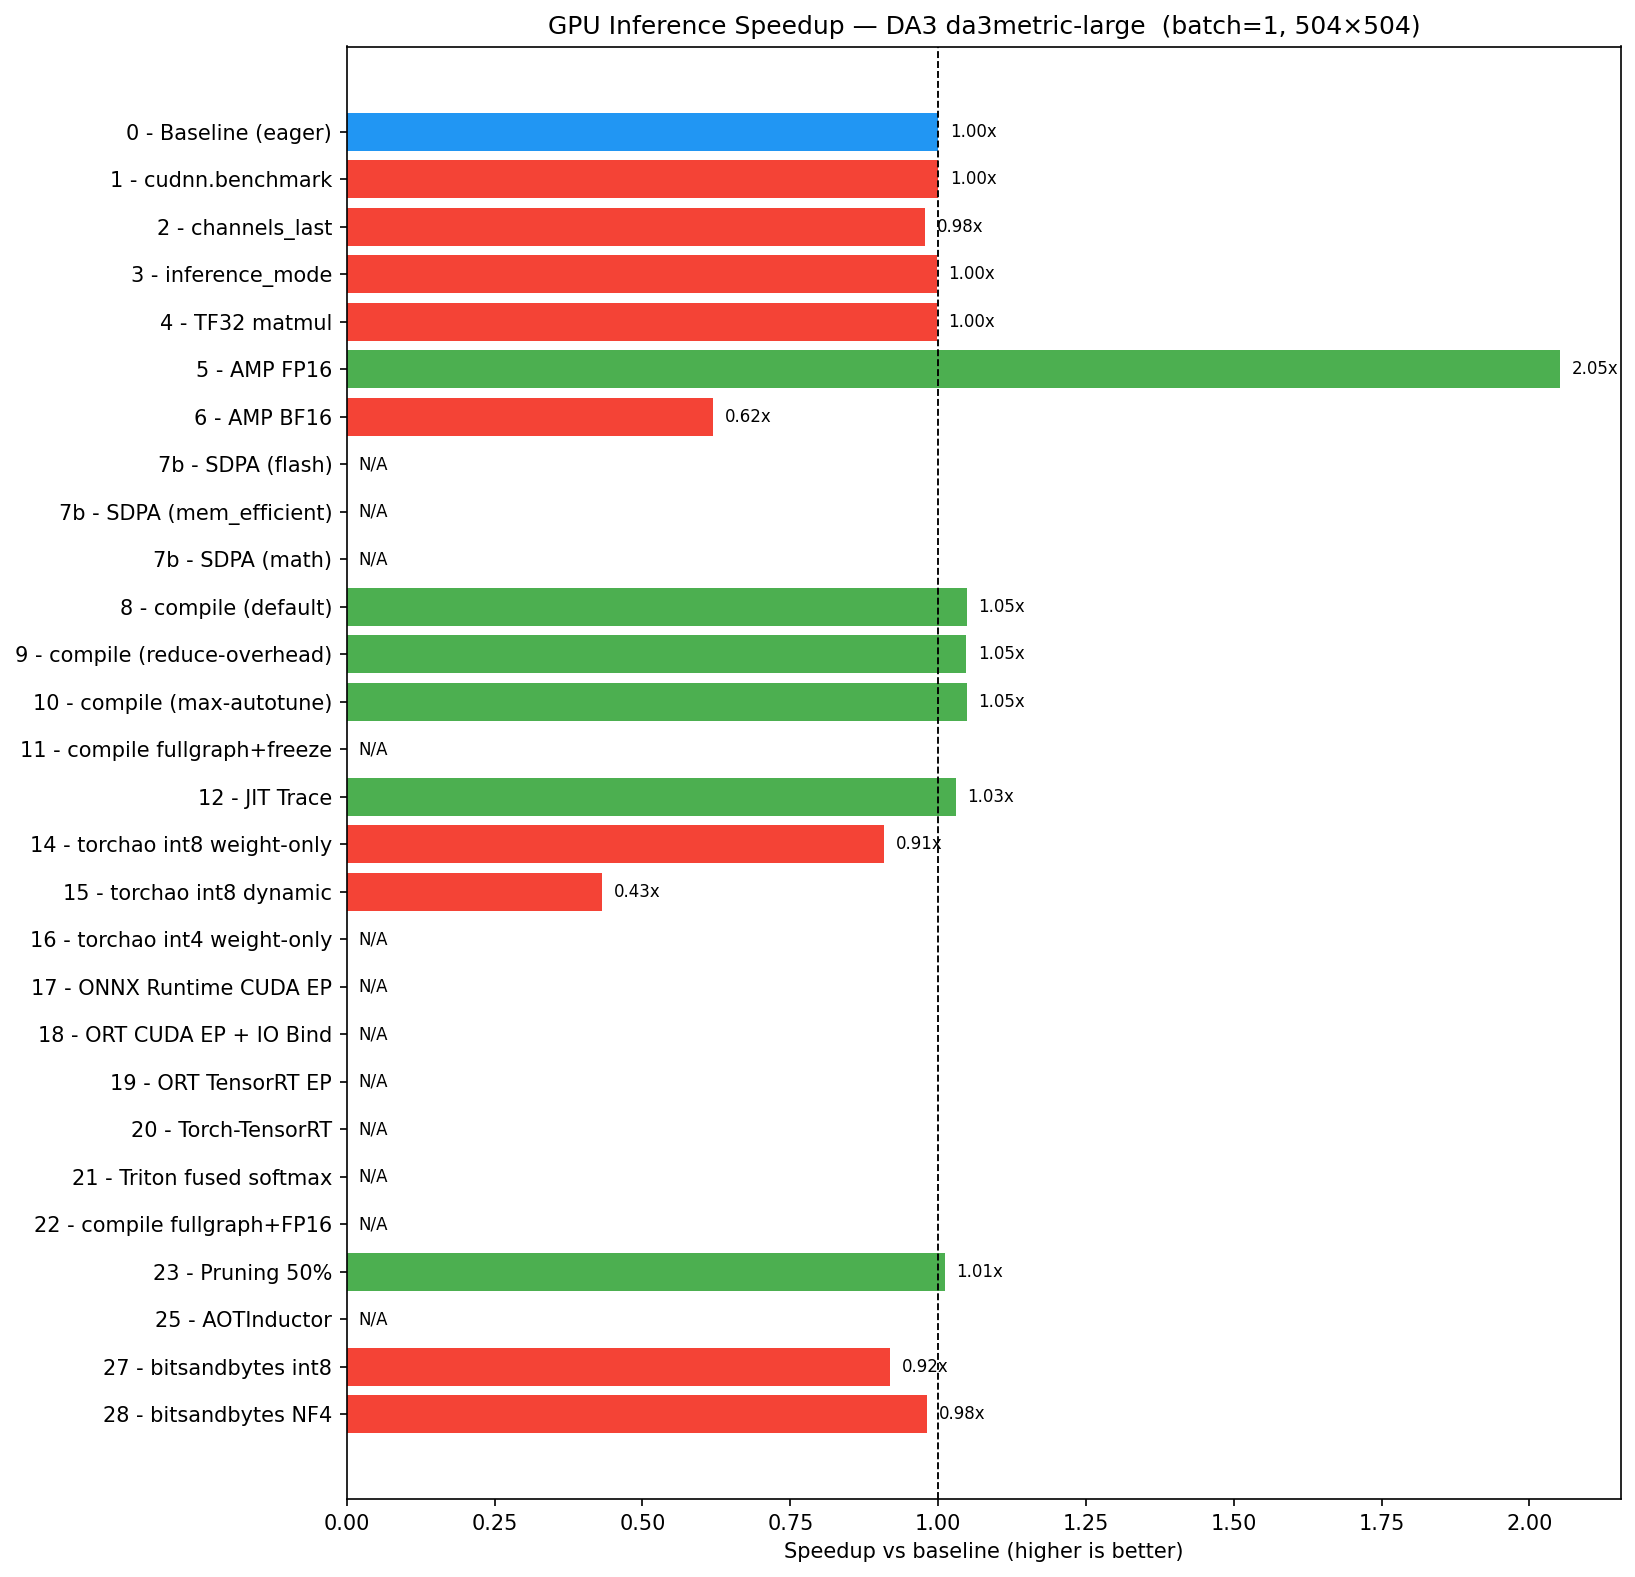

In [42]:
def _speedup_chart(results, baseline_key, title, filename):
    bl = results.get(baseline_key, 1.0)
    items = list(results.items())
    names    = [k for k, _ in items]
    speedups = [bl / v if (v == v and v > 0) else 0 for _, v in items]
    colors   = [
        ("#2196F3" if n == baseline_key else "#4CAF50" if s >= 1.0 else "#F44336")
        for n, s in zip(names, speedups)
    ]

    fig, ax = plt.subplots(figsize=(11, max(5, len(names) * 0.38)))
    bars = ax.barh(names, speedups, color=colors)
    ax.axvline(x=1.0, color="black", linewidth=0.9, linestyle="--", label="baseline")
    ax.set_xlabel("Speedup vs baseline (higher is better)")
    ax.set_title(title)
    ax.invert_yaxis()

    for bar, s, (n, _) in zip(bars, speedups, items):
        lbl = f"{s:.2f}x" if s > 0 else "N/A"
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                lbl, va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved {filename}")


_speedup_chart(
    GPU_RESULTS,
    "0 - Baseline (eager)",
    f"GPU Inference Speedup — DA3 {MODEL_NAME}  (batch={BATCH}, 504×504)",
    "inference_benchmark_gpu.png",
)
IPImage(filename="inference_benchmark_gpu.png")

---
## What we learned

### The free wins (everyone should use these)

- **`TF32 matmul`** — On Ampere+ GPUs (A100, RTX 30xx, H100), TF32 rounds float32
  mantissa bits from 23 to 10 before the hardware tensor core matmul, then rounds back.
  About 2× faster for free. On V100 (pre-Ampere) there are no TF32 tensor cores so
  this is a no-op.

- **`inference_mode`** — Stricter than `no_grad`: also disables autograd version counters
  and view tracking. A few percent faster, zero accuracy cost.

- **`model.half()` (FP16)** — Halves memory bandwidth. On V100 the Tensor Cores do
  FP16 × FP16 → FP32 accumulation, so this is the single biggest easy win.

### The compiler wins (need Triton / Linux)

- **`torch.compile`** — TorchDynamo traces your model, TorchInductor compiles it via
  Triton. `reduce-overhead` uses CUDA Graphs internally — best for batch=1. Combined
  with FP16 this is the "GPT, Fast" recipe.

- **`fullgraph=True`** forces zero graph breaks. If it works (no dynamic control flow),
  the compiler optimizes the entire model as one fused kernel graph.

### Depth estimation gotchas

- **DA3's inner model uses `autocast(enabled=False)`** for the DPT depth head: this
  means AMP FP16 only accelerates the backbone (DinoV2), while the head always runs
  in FP32. Static FP16 (`model.half()`) is more effective but may lose precision in
  the depth head's convolutions.

- **`addict.Dict` output** — DA3 returns an `addict.Dict` internally, which can cause
  graph breaks in `torch.compile` and issues with JIT trace. The `DA3Depth` wrapper
  extracts just the depth tensor for compatibility.

### Why some techniques are slow or fail

- **`channels_last`** — Designed for CNNs (NHWC layout). DA3's backbone is mostly
  `nn.Linear`; only the DPT head's convolutions benefit, so the gain is tiny.

- **TensorRT** — TRT 10.x requires **SM ≥ 8.0** (Ampere). On V100 (SM 7.0) it fails.

- **bitsandbytes int8/NF4** — Custom dequantization kernels on V100 don't match
  hardware matmul throughput. Best for memory-constrained scenarios.

- **Pruning 50 %** — No hardware sparse support on V100 (that's Ampere 2:4 sparsity).

### The quantization landscape

- **torchao int8 weight-only** — 2× memory reduction; dequant fuses with `torch.compile`.
- **torchao int4** — 4× reduction vs FP16; custom Triton kernels.
- **ONNX int8 static** — Calibrated QDQ format for ORT deployment.

### References

1. **Depth Anything v3**: ByteDance-Seed, 2025. https://github.com/ByteDance-Seed/depth-anything-3
2. **DINOv2**: Oquab et al., 2023. https://arxiv.org/abs/2304.07193
3. **GPT, Fast**: PyTorch Blog, 2023. https://pytorch.org/blog/accelerating-generative-ai-2/
4. **LLM.int8()**: Dettmers et al., 2022. https://arxiv.org/abs/2208.07339
5. **QLoRA (NF4)**: Dettmers et al., 2023. https://arxiv.org/abs/2305.14314
6. **torch.compile**: PyTorch 2.0 blog, 2023.
7. **gpu-mode lectures**: https://github.com/gpu-mode/lectures
8. **FlashAttention**: Dao et al., 2022. https://arxiv.org/abs/2205.14135
9. **ONNX Runtime**: https://onnxruntime.ai/
10. **TensorRT**: https://developer.nvidia.com/tensorrt
11. **torchao**: https://github.com/pytorch/ao
12. **PyTorch Serve performance checklist**: https://docs.pytorch.org/serve/performance_checklist.html
13. **NVIDIA inference optimization**: https://developer.nvidia.com/blog/tag/inference-performance/

---
## Cleanup

Remove temporary files generated during the benchmark run.

In [43]:
import glob

_temp_patterns = [
    "model.onnx", "model_prep.onnx", "model_int8.onnx",
    "model_scripted.pt", "inference_benchmark_gpu.png",
]

for _pat in _temp_patterns:
    for _f in glob.glob(_pat):
        try:
            os.remove(_f)
            print(f"  removed {_f}")
        except OSError:
            pass

print("Cleanup done.")

  removed model.onnx
  removed model_int8.onnx
  removed inference_benchmark_gpu.png
Cleanup done.
